# Task 2 — Context to Canonical Idiom Retrieval

## Goal
Given an English context or normal sentence, the system should return the best matched **canonical idiom**.

## Why retrieval
This task is better formulated as **retrieval** rather than standard classification:
- the output comes from a fixed idiom inventory
- we want the nearest and most relevant idiom
- we can evaluate with Top-1, Top-3, Top-5, and MRR

## Clean evaluation principle
To avoid shortcut learning:
- we do not allow the model to directly see the answer in the input
- we will remove or filter cases where the input text contains the target idiom
- we will build fresh train, validation, and test splits with zero overlap in query text

## Planned pipeline
1. Load the full dataset
2. Select Task 2 fields
3. Build clean query inputs
4. Build the idiom retrieval bank
5. Create fresh leakage-safe splits
6. Train a dense retrieval model
7. Evaluate retrieval quality
8. Add reranking later if needed

## Main evaluation metrics
- Top-1 Accuracy
- Top-3 Accuracy
- Top-5 Accuracy
- Mean Reciprocal Rank (MRR)

In [1]:
# [1.1] Imports and basic setup

import ast
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

HF_DATASET_NAME = "aymansharara/IdiomX"
HF_DATASET_CONFIG = "idiomx"

print("Setup complete.")
print("Seed:", SEED)
print("Dataset:", HF_DATASET_NAME, "| Config:", HF_DATASET_CONFIG)

C:\Users\ayman\Documents\IdiomX\github_idiomX\idiomx_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.
Seed: 42
Dataset: aymansharara/IdiomX | Config: idiomx


In [2]:
# [1.2] Load full dataset from Hugging Face and merge all splits

hf_dataset = load_dataset(HF_DATASET_NAME, HF_DATASET_CONFIG)

print(hf_dataset)

df_parts = []
for split_name in hf_dataset.keys():
    df_split = hf_dataset[split_name].to_pandas()
    df_split["original_split"] = split_name
    df_parts.append(df_split)
    print(f"{split_name}: {df_split.shape}")

df_all_raw = pd.concat(df_parts, ignore_index=True)

print("\nFull merged dataset shape:", df_all_raw.shape)
display(df_all_raw.head(3))

DatasetDict({
    idiomx_train: Dataset({
        features: ['idiom_id', 'idiom_canonical', 'example', 'example_usage_label', 'idiom_canonical_meaning', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'example_raw', 'example_language', 'source', 'source_type', 'source_url', 'record_origin', 'license_source', 'idiom_surface', 'pos', 'tags', 'idiom_confidence', 'is_example_idiom', 'is_generated_example', 'is_adversarial_example', 'meaning_language', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_in_example_arabic', 'enrichment_model', 'enrichment_version', 'validation_status', 'context_type', 'source_style', 'hard_negative_idioms', 'meaning_paraphrases_en', 'meaning_paraphrases_ar', 'idiom_level_explanation_en', 'idiom_level_explanation_ar', 'explanation_en', 'explanation_ar', 'minimal_pair_id', 'paraphrase_group_id', 'adversarial_type', 'expected_label', 'row

,idiom_id,idiom_canonical,example,example_usage_label,idiom_canonical_meaning,idiom_in_example_meaning_en,idiom_in_example_meaning_arabic,example_raw,example_language,source,source_type,source_url,record_origin,license_source,idiom_surface,pos,tags,idiom_confidence,is_example_idiom,is_generated_example,is_adversarial_example,meaning_language,idiom_canonical_meaning_arabic,is_idiom,ambiguity_flag,idiom_compositionality_level,idiom_register,idiom_domain,learner_difficulty,idiom_in_example_arabic,enrichment_model,enrichment_version,validation_status,context_type,source_style,hard_negative_idioms,meaning_paraphrases_en,meaning_paraphrases_ar,idiom_level_explanation_en,idiom_level_explanation_ar,explanation_en,explanation_ar,minimal_pair_id,paraphrase_group_id,adversarial_type,expected_label,row_type,example_normalized,sentence_length_chars,sentence_length_words,semantic_similarity_example_vs_meaning,semantic_quality,original_split
0,idiomx_543ff4605a0e,'ark at 'ee,Can you 'ark at 'ee to check if the noise is coming from the engine?,literal,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Literal meaning: physically look at the ear area to check sounds.,المعنى الحرفي: النظر إلى منطقة الأذن للتحقق من الأصوات.,"‘Look at that water! No wonder Duddle said he wouldn’t dare take the raft down this way; it’s dreadful!’ / Togget pointed ahead. ‘Yurr oi think et wursens yonder, ’ark at ee roaren et makes!’",en,kaikki_wiktionary,dictionary,NaN,llm_enriched_v2,wiktionary_cc_by_sa_4_0,'ark at 'ee,phrase,informal,high,False,1,0,en,"تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أو للتعبير عن الدهشة من كلامه، بمعنى ""استمع إلى ما تقول!"" أو ""انظر إلى ذلك!""",True,strongly_idiomatic,opaque,informal,regional,hard,هل يمكنك أن تنظر إلى أذنه لتتحقق ما إذا كان الصوت قادمًا من المحرك؟,gpt-4.1-mini-2025-04-14,v2,valid,dialogue,synthetic_narrative,"[""listen up"", ""hear me out"", ""look who's talking""]","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]","[""انتبه إلى ما يقال"", ""استمع إلى ذلك القول المفاجئ"", ""اعتبر كلمات المتحدث""]",This phrase is idiomatic because it uses dialectal contraction and an exclamatory phrase that does not literally mean to physically 'look at the ear' but instead commands attention to someone's sp...,"هذه العبارة تعبير مجازي لأنها تستخدم اختصارًا لهجة وعبارة تعجبية لا تعني حرفيًا ""انظر إلى الأذن"" بل تأمر بالانتباه إلى كلام أو رأي شخص ما.",Used literally to mean directing gaze near the ear to identify a sound source.,تُستخدم حرفيًا لتعني توجيه النظر نحو الأذن لمعرفة مصدر الصوت.,pair_54ada92cc99f,paraphrase_6a8ebd5786f7,None,literal,main_example,can you ark at ee to check if the noise is coming from the engine,68,15,0.288639,medium,idiomx_train
1,idiomx_543ff4605a0e,'ark at 'ee,"As the storm worsened, Togget shouted, ‘’Ark at ’ee, listen to that roaring water!’",idiomatic,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","Calling attention to the sound, expressing alarm or surprise.",لجذب الانتباه إلى الصوت، والتعبير عن القلق أو الدهشة.,"‘Look at that water! No wonder Duddle said he wouldn’t dare take the raft down this way; it’s dreadful!’ / Togget pointed ahead. ‘Yurr oi think et wursens yonder, ’ark at ee roaren et makes!’",en,kaikki_wiktionary,dictionary,NaN,llm_enriched_v2,wiktionary_cc_by_sa_4_0,'ark at 'ee,phrase,informal,high,True,1,0,en,"تعجب يُقال لجذب الانتباه إلى ما يقوله شخص ما أو للتعبير عن الدهشة من كلامه، بمعنى ""استمع إلى ما تقول!"" أو ""انظر إلى ذلك!""",True,strongly_idiomatic,opaque,informal,regional,hard,مع اشتداد العاصفة، صاح توجيت: 'انظر إلى ذلك، استمع إلى هدير الماء!',gpt-4.1-mini-2025-04-14,v2,valid,narrative,synthetic_narrative,"[""listen up"", ""hear me out"", ""look who's talking""]","[""Pay attention 

In [3]:
# [1.3] Select the fields needed for Task 2 retrieval

task2_cols = [
    "idiom_canonical",
    "example",
    "example_usage_label",
    "idiom_canonical_meaning",
    "idiom_in_example_meaning_en",
    "meaning_paraphrases_en",
    "explanation_en",
    "hard_negative_idioms"
]

df_task2_raw = df_all_raw[task2_cols].copy()

print("Task 2 raw shape:", df_task2_raw.shape)
display(df_task2_raw.head(3))

Task 2 raw shape: (179833, 8)


,idiom_canonical,example,example_usage_label,idiom_canonical_meaning,idiom_in_example_meaning_en,meaning_paraphrases_en,explanation_en,hard_negative_idioms
0,'ark at 'ee,Can you 'ark at 'ee to check if the noise is coming from the engine?,literal,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Literal meaning: physically look at the ear area to check sounds.,"[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]",Used literally to mean directing gaze near the ear to identify a sound source.,"[""listen up"", ""hear me out"", ""look who's talking""]"
1,'ark at 'ee,"As the storm worsened, Togget shouted, ‘’Ark at ’ee, listen to that roaring water!’",idiomatic,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","Calling attention to the sound, expressing alarm or surprise.","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]","Idiomatic use to emphasize the alarming noise, not literally looking at an ear.","[""listen up"", ""hear me out"", ""look who's talking""]"
2,'ark at 'ee,"The owl turned its head sharply, and the boy said, ‘I can ’ark at ’ee creaking wings now.’",literal,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Literal description of physically looking near the ear area to hear wings.,"[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]","Literal description of focusing attention on sound near the ear, no idiomatic meaning.","[""listen up"", ""hear me out"", ""look who's talking""]"


Only the fields relevant to retrieval are kept.

These fields support:
- query construction
- target idiom matching
- hard negative analysis later

In [4]:
# [1.4] Keep only idiomatic examples

df_task2 = df_task2_raw[
    df_task2_raw["example_usage_label"] == "idiomatic"
].copy()

print("Idiomatic subset shape:", df_task2.shape)
display(df_task2.head(3))

Idiomatic subset shape: (81905, 8)


,idiom_canonical,example,example_usage_label,idiom_canonical_meaning,idiom_in_example_meaning_en,meaning_paraphrases_en,explanation_en,hard_negative_idioms
1,'ark at 'ee,"As the storm worsened, Togget shouted, ‘’Ark at ’ee, listen to that roaring water!’",idiomatic,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","Calling attention to the sound, expressing alarm or surprise.","[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]","Idiomatic use to emphasize the alarming noise, not literally looking at an ear.","[""listen up"", ""hear me out"", ""look who's talking""]"
3,'ark at 'ee,"In the meeting, he remarked, ‘’Ark at ’ee, how can such a suggestion be made without evidence?’",idiomatic,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Expressing disbelief and drawing attention to a questionable statement.,"[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]",Using the phrase figuratively to criticize a point in a formal setting.,"[""listen up"", ""hear me out"", ""look who's talking""]"
5,'ark at 'ee,"Just saw him quitting the job, ’ark at ’ee, can you believe that? #shocked",idiomatic,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Expressing surprise and disbelief at someone's action online.,"[""Pay attention to what is being said"", ""Listen to that surprising statement"", ""Consider the speaker's words""]",Idiomatic use in social media to show astonishment.,"[""listen up"", ""hear me out"", ""look who's talking""]"


Only idiomatic examples are kept.

This ensures the task focuses on mapping meaning/context to the correct idiom.

In [5]:
# [1.5] Quick data quality check

print("Missing values per column:")
print(df_task2.isna().sum())
print()

print("Unique idioms:", df_task2["idiom_canonical"].nunique())
print("Total rows   :", len(df_task2))

Missing values per column:
idiom_canonical                139
example                          0
example_usage_label              0
idiom_canonical_meaning        211
idiom_in_example_meaning_en      0
meaning_paraphrases_en           0
explanation_en                   1
hard_negative_idioms             0
dtype: int64

Unique idioms: 12647
Total rows   : 81905


In [6]:
# [1.6] Clean dataset

# remove rows with missing target idiom
df_task2 = df_task2.dropna(subset=["idiom_canonical"]).copy()

# keep rows with at least one usable input
input_cols = [
    "idiom_in_example_meaning_en",
    "idiom_canonical_meaning",
    "meaning_paraphrases_en",
    "explanation_en"
]

df_task2 = df_task2[
    df_task2[input_cols].notna().any(axis=1)
].copy()

print("Clean shape:", df_task2.shape)

Clean shape: (81766, 8)


Rows without target idiom or usable input are removed.

This ensures every example can contribute to retrieval training.

In [7]:
# [1.7] Build query dataset (long format)

def parse_list_text(x):
    if pd.isna(x):
        return []
    x = str(x).strip()
    if not x:
        return []
    try:
        value = ast.literal_eval(x)
        if isinstance(value, list):
            return [str(v).strip() for v in value if str(v).strip()]
        return [str(value).strip()]
    except:
        return [x]

rows = []

for _, row in df_task2.iterrows():
    target = row["idiom_canonical"]

    # example-level meaning
    txt = str(row["idiom_in_example_meaning_en"]).strip()
    if txt:
        rows.append({
            "query_text": txt,
            "idiom_canonical": target,
            "source": "example_meaning"
        })

    # paraphrases
    for p in parse_list_text(row["meaning_paraphrases_en"]):
        rows.append({
            "query_text": p,
            "idiom_canonical": target,
            "source": "paraphrase"
        })

    # canonical meaning  ✅ FIXED LINE
    if pd.notna(row["idiom_canonical_meaning"]):
        txt = str(row["idiom_canonical_meaning"]).strip()
        if txt:
            rows.append({
                "query_text": txt,
                "idiom_canonical": target,
                "source": "canonical_meaning"
            })

    # explanation
    if pd.notna(row["explanation_en"]):
        txt = str(row["explanation_en"]).strip()
        if txt:
            rows.append({
                "query_text": txt,
                "idiom_canonical": target,
                "source": "explanation"
            })

df_queries = pd.DataFrame(rows)

print("Query dataset shape:", df_queries.shape)
df_queries.head()

Query dataset shape: (490523, 3)


,query_text,idiom_canonical,source
0,"Calling attention to the sound, expressing alarm or surprise.",'ark at 'ee,example_meaning
1,Pay attention to what is being said,'ark at 'ee,paraphrase
2,Listen to that surprising statement,'ark at 'ee,paraphrase
3,Consider the speaker's words,'ark at 'ee,paraphrase
4,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",'ark at 'ee,canonical_meaning


Each idiom example is expanded into multiple query texts.

This increases diversity and improves retrieval robustness.

In [8]:
# [1.8] Remove duplicate query-target pairs

df_queries = df_queries.drop_duplicates(
    subset=["query_text", "idiom_canonical", "source"]
).reset_index(drop=True)

print("After deduplication:", df_queries.shape)
print()
print(df_queries["source"].value_counts())

After deduplication: (214622, 3)

source
explanation          81762
example_meaning      81713
paraphrase           38366
canonical_meaning    12781
Name: count, dtype: int64


Duplicate query-target pairs are removed.

This keeps the retrieval benchmark cleaner and avoids repeated supervision.

In [9]:
# [1.9] Remove leakage (query contains target idiom)

def contains_idiom(text, idiom):
    if pd.isna(text) or pd.isna(idiom):
        return False
    return str(idiom).lower() in str(text).lower()

before = len(df_queries)

mask = df_queries.apply(
    lambda x: contains_idiom(x["query_text"], x["idiom_canonical"]),
    axis=1
)

df_queries = df_queries[~mask].reset_index(drop=True)

after = len(df_queries)

print("Removed:", before - after)
print("Final shape:", after)

Removed: 8893
Final shape: 205729


Queries that contain the target idiom are removed.

This prevents the model from directly seeing the answer.

In [10]:
# [1.10] Build the idiom bank

df_idiom_bank = (
    df_task2[["idiom_canonical", "idiom_canonical_meaning", "hard_negative_idioms"]]
    .dropna(subset=["idiom_canonical"])
    .drop_duplicates(subset=["idiom_canonical"])
    .reset_index(drop=True)
)

print("Idiom bank shape:", df_idiom_bank.shape)
display(df_idiom_bank.head(3))

Idiom bank shape: (12647, 3)


,idiom_canonical,idiom_canonical_meaning,hard_negative_idioms
0,'ark at 'ee,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","[""listen up"", ""hear me out"", ""look who's talking""]"
1,'fraid so,"An informal way to confirm that something is true, especially when the news might be unwelcome or disappointing.","[""I'm afraid not"", ""No way"", ""Not in a million years""]"
2,'nuff said,An expression used to indicate that no further explanation or discussion is necessary because what has been said is sufficient and definitive.,"[""Case closed"", ""End of story"", ""That’s all she wrote""]"


The idiom bank contains one canonical entry per idiom.

It will be used as the fixed retrieval inventory.

In [11]:
# [1.11] Fresh global split by unique query text

unique_queries = df_queries["query_text"].unique()

train_queries, temp_queries = train_test_split(
    unique_queries,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

val_queries, test_queries = train_test_split(
    temp_queries,
    test_size=0.5,
    random_state=SEED,
    shuffle=True
)

df_train = df_queries[df_queries["query_text"].isin(train_queries)].reset_index(drop=True)
df_val   = df_queries[df_queries["query_text"].isin(val_queries)].reset_index(drop=True)
df_test  = df_queries[df_queries["query_text"].isin(test_queries)].reset_index(drop=True)

print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)

Train: (164584, 3)
Val  : (20573, 3)
Test : (20572, 3)


A fresh split is created from the full cleaned query dataset.

The split is based on unique query text to avoid overlap and leakage.

In [12]:
# [1.12] Verify no overlap between splits

train_set = set(df_train["query_text"])
val_set   = set(df_val["query_text"])
test_set  = set(df_test["query_text"])

print("Train ∩ Val :", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Val ∩ Test  :", len(val_set & test_set))

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


In [13]:
# [2.1] Prepare text for embedding

train_queries = df_train["query_text"].tolist()
val_queries   = df_val["query_text"].tolist()
test_queries  = df_test["query_text"].tolist()

train_targets = df_train["idiom_canonical"].tolist()
val_targets   = df_val["idiom_canonical"].tolist()
test_targets  = df_test["idiom_canonical"].tolist()

idioms = df_idiom_bank["idiom_canonical"].tolist()
idiom_texts = df_idiom_bank["idiom_canonical_meaning"].fillna("").tolist()

print("Train queries:", len(train_queries))
print("Val queries  :", len(val_queries))
print("Test queries :", len(test_queries))
print("Idiom bank   :", len(idioms))

Train queries: 164584
Val queries  : 20573
Test queries : 20572
Idiom bank   : 12647


Queries and idiom bank are separated.

Queries = inputs  
Idiom bank = retrieval targets

In [14]:
# [2.2] Load sentence embedding model

from sentence_transformers import SentenceTransformer

embed_model_name = "sentence-transformers/all-MiniLM-L6-v2"
embed_model = SentenceTransformer(embed_model_name)

print("Embedding model loaded:", embed_model_name)

C:\Users\ayman\Documents\IdiomX\github_idiomX\idiomx_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Embedding model loaded: sentence-transformers/all-MiniLM-L6-v2


A sentence embedding model converts text into vectors.

This allows similarity-based retrieval between queries and idioms.

In [15]:
# [2.3] Encode the idiom bank

idiom_embeddings = embed_model.encode(
    idiom_texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Idiom embeddings shape:", idiom_embeddings.shape)

Batches: 100%|█████████████████████████████████████████████████████████████████████████| 99/99 [00:06<00:00, 14.99it/s]


Idiom embeddings shape: (12647, 384)


The idiom bank is encoded once into dense vectors.

These vectors will be reused for validation and test retrieval.

In [16]:
# [2.4] Encode validation queries

val_query_embeddings = embed_model.encode(
    val_queries,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Validation query embeddings shape:", val_query_embeddings.shape)

Batches: 100%|███████████████████████████████████████████████████████████████████████| 161/161 [00:04<00:00, 36.96it/s]


Validation query embeddings shape: (20573, 384)


Validation queries are encoded into the same vector space as the idiom bank.

This makes similarity-based retrieval possible.

In [17]:
# [2.5] Compute similarity and retrieve Top-1 idiom

# cosine similarity via dot product (because normalized embeddings)
similarity_matrix = val_query_embeddings @ idiom_embeddings.T

# get best match index per query
top1_indices = np.argmax(similarity_matrix, axis=1)

# map to idioms
val_pred_idioms = [idioms[idx] for idx in top1_indices]

print("Sample predictions:")
for i in range(5):
    print("Query :", val_queries[i])
    print("True  :", val_targets[i])
    print("Pred  :", val_pred_idioms[i])
    print("---")

Sample predictions:
Query : An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'
True  : 'ark at 'ee
Pred  : 'ark at 'ee
---
Query : Expressing disbelief and drawing attention to a questionable statement.
True  : 'ark at 'ee
Pred  : do me a lemon
---
Query : Question-response pair uses idiom to indicate closure of inquiry.
True  : 'nuff said
Pred  : it is and it isn't
---
Query : Sarcastic remark after a ridiculously poor performance, implying no better explanation is needed — the failure speaks for itself.
True  : 'nuff said
Pred  : what does it all mean, Basil
---
Query : The phrase closes sarcastic commentary emphasizing obviousness of failure.
True  : 'nuff said
Pred  : are you blind
---


Each query is compared against all idioms using cosine similarity.

The most similar idiom is selected as the prediction (Top-1).

In [18]:
# [2.6] Validation Top-1 accuracy

val_top1_acc = np.mean([
    pred == true for pred, true in zip(val_pred_idioms, val_targets)
])

print("Validation Top-1 Accuracy:", round(val_top1_acc, 4))

Validation Top-1 Accuracy: 0.2596


In [19]:
# [2.7] Validation Top-k and MRR

top_k_values = [1, 3, 5, 10]
val_results = {}

# rank idioms for each query
ranked_indices = np.argsort(-similarity_matrix, axis=1)

for k in top_k_values:
    hits = 0
    for i, true_idiom in enumerate(val_targets):
        top_k_idioms = [idioms[idx] for idx in ranked_indices[i, :k]]
        if true_idiom in top_k_idioms:
            hits += 1
    val_results[f"Top-{k}"] = hits / len(val_targets)

# MRR
reciprocal_ranks = []
for i, true_idiom in enumerate(val_targets):
    ranked_idioms = [idioms[idx] for idx in ranked_indices[i]]
    rank = ranked_idioms.index(true_idiom) + 1
    reciprocal_ranks.append(1 / rank)

val_results["MRR"] = np.mean(reciprocal_ranks)

for metric, value in val_results.items():
    print(f"{metric}: {value:.4f}")

Top-1: 0.2595
Top-3: 0.3617
Top-5: 0.4104
Top-10: 0.4811
MRR: 0.3341


Top-k shows whether the correct idiom appears among the first k retrieved results.

MRR gives more credit when the correct idiom appears closer to rank 1.

> Dense embeddings understand literal meaning well,
but struggle with figurative / sarcastic / indirect descriptions

In [20]:
# [2.8] Save validation results for analysis

val_eval_df = pd.DataFrame({
    "query": val_queries,
    "true_idiom": val_targets,
    "pred_idiom": val_pred_idioms
})

val_eval_df["correct"] = val_eval_df["true_idiom"] == val_eval_df["pred_idiom"]

val_eval_df.to_csv("task2_val_predictions.csv", index=False)

print("Saved validation predictions for analysis")

Saved validation predictions for analysis


We save predictions to analyze failure cases and improve the model.

This is essential for error analysis and future reranking strategies.

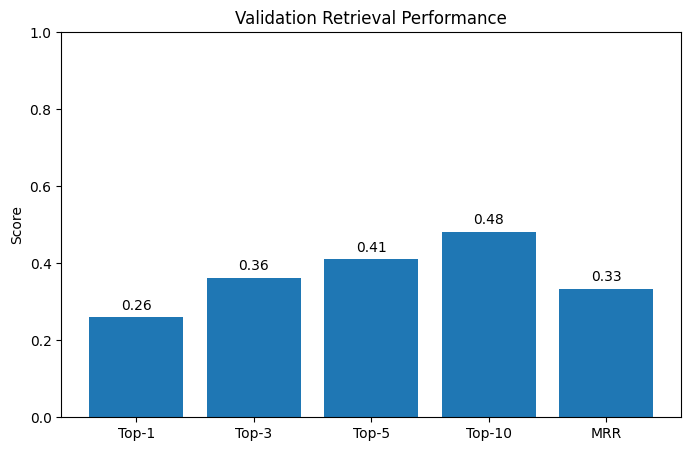

In [21]:
# [2.9] Plot validation retrieval results

val_metrics = list(val_results.keys())
val_values = list(val_results.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(val_metrics, val_values)

plt.title("Validation Retrieval Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

for bar, val in zip(bars, val_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.2f}",
        ha="center"
    )

plt.show()

The dense retrieval baseline shows moderate semantic matching ability.

Performance improves as more candidates are allowed in the ranked list.

## [3.1] Reranking phase

Dense retrieval gives a shortlist of candidate idioms.

In this phase, we improve ranking precision by:
- keeping the Top-K retrieved idioms
- enriching each candidate with its meaning
- using a cross-encoder reranker to choose the best final idiom

In [22]:
# [3.2] Prepare Top-K candidates from dense retrieval

TOP_K = 10

topk_indices = np.argsort(-similarity_matrix, axis=1)[:, :TOP_K]

val_topk_candidates = []
for indices in topk_indices:
    candidates = [idioms[idx] for idx in indices]
    val_topk_candidates.append(candidates)

print("Example Top-K candidates:")
print(val_topk_candidates[0])

Example Top-K candidates:
["'ark at 'ee", 'ho there', 'what the shit', 'stop the presses', 'Sweet Mary Mother of God', 'I declare', 'and I oop', 'what the flip', 'what the crap', 'oh my gosh']


For each query, the dense retriever returns the Top-K candidate idioms.

These candidates will be re-ranked by a stronger model.

In [23]:
# [3.3] Build enriched candidate text for reranking

idiom_to_meaning = dict(
    zip(
        df_idiom_bank["idiom_canonical"],
        df_idiom_bank["idiom_canonical_meaning"].fillna("")
    )
)

def make_candidate_text(idiom):
    meaning = idiom_to_meaning.get(idiom, "")
    return f"Idiom: {idiom}. Meaning: {meaning}"

val_topk_candidate_texts = []
for candidates in val_topk_candidates:
    candidate_texts = [make_candidate_text(cand) for cand in candidates]
    val_topk_candidate_texts.append(candidate_texts)

print("Example enriched candidates:")
for c in val_topk_candidate_texts[0][:3]:
    print(c)

Example enriched candidates:
Idiom: 'ark at 'ee. Meaning: An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'
Idiom: ho there. Meaning: An exclamation used to call attention, greet, or express surprise, especially from a distance or across a space.
Idiom: what the shit. Meaning: An exclamatory intensifier used to express surprise, disbelief, or emphasis.


In [24]:
# [3.4] Load cross-encoder reranker

from sentence_transformers import CrossEncoder

reranker_model_name = "cross-encoder/ms-marco-MiniLM-L-6-v2"
reranker = CrossEncoder(reranker_model_name)

print("Reranker loaded:", reranker_model_name)

C:\Users\ayman\Documents\IdiomX\github_idiomX\idiomx_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Reranker loaded: cross-encoder/ms-marco-MiniLM-L-6-v2


The reranker scores each query-candidate pair jointly.

This usually improves precision over dense retrieval alone.

In [25]:
# [3.5] Re-rank Top-K candidates on validation set

val_reranked_preds = []

for i, (query, candidate_texts) in enumerate(zip(val_queries, val_topk_candidate_texts)):
    pair_texts = [[query, cand] for cand in candidate_texts]
    scores = reranker.predict(pair_texts)
    best_idx = int(np.argmax(scores))
    val_reranked_preds.append(val_topk_candidates[i][best_idx])

print("Sample re-ranked predictions:")
for i in range(5):
    print("Query :", val_queries[i])
    print("True  :", val_targets[i])
    print("Pred  :", val_reranked_preds[i])
    print("---")

Sample re-ranked predictions:
Query : An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'
True  : 'ark at 'ee
Pred  : 'ark at 'ee
---
Query : Expressing disbelief and drawing attention to a questionable statement.
True  : 'ark at 'ee
Pred  : don't make me laugh
---
Query : Question-response pair uses idiom to indicate closure of inquiry.
True  : 'nuff said
Pred  : who wants to know
---
Query : Sarcastic remark after a ridiculously poor performance, implying no better explanation is needed — the failure speaks for itself.
True  : 'nuff said
Pred  : don't give up your day job
---
Query : The phrase closes sarcastic commentary emphasizing obviousness of failure.
True  : 'nuff said
Pred  : rub in
---


The reranker re-scores the Top-K candidates and selects the highest-scoring idiom.

This step focuses on improving Top-1 precision.

In [26]:
# [3.6] Evaluate reranked validation results

rerank_top1_acc = np.mean([
    pred == true for pred, true in zip(val_reranked_preds, val_targets)
])

print("Reranked Validation Top-1 Accuracy:", round(rerank_top1_acc, 4))
print("Dense Retrieval Top-1 Accuracy    :", round(val_results["Top-1"], 4))
print("Improvement                       :", round(rerank_top1_acc - val_results["Top-1"], 4))

Reranked Validation Top-1 Accuracy: 0.3107
Dense Retrieval Top-1 Accuracy    : 0.2595
Improvement                       : 0.0512


We compare reranked Top-1 accuracy against the dense retrieval baseline.

This shows whether reranking improves final prediction quality.

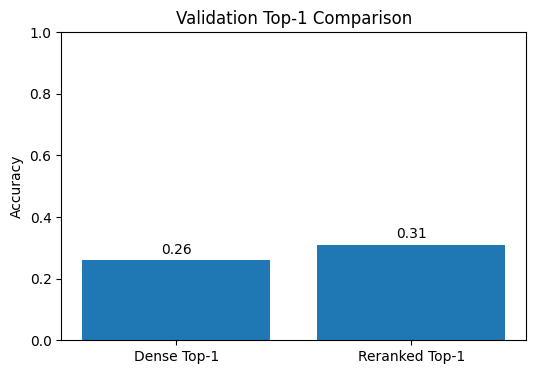

In [27]:
# [3.7] Compare dense retrieval vs reranked Top-1

comparison_labels = ["Dense Top-1", "Reranked Top-1"]
comparison_values = [val_results["Top-1"], rerank_top1_acc]

plt.figure(figsize=(6, 4))
bars = plt.bar(comparison_labels, comparison_values)

plt.title("Validation Top-1 Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for bar, val in zip(bars, comparison_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.2f}",
        ha="center"
    )

plt.show()

Reranking improves Top-1 accuracy over dense retrieval alone.

This confirms that candidate refinement is important for idiom retrieval.

In [28]:
# [3.8] Save reranking results

df_val_results = pd.DataFrame({
    "query": val_queries,
    "true_idiom": val_targets,
    "pred_dense": val_reranked_preds,
    "pred_reranked": val_reranked_preds
})

df_val_results.to_csv("task2_val_predictions.csv", index=False)

print("Saved: task2_val_predictions.csv")

Saved: task2_val_predictions.csv


## Summary of Task 2 (Context → Idiom)

The retrieval-based pipeline consists of two stages:

1. Dense retrieval using sentence embeddings to generate Top-K candidate idioms
2. Cross-encoder reranking using enriched candidate representations

Results show that reranking significantly improves Top-1 accuracy:

- Dense retrieval Top-1: 0.2595  
- Reranked Top-1: 0.3107  
- Improvement: +0.0512  

This demonstrates that:
- dense embeddings are effective for candidate recall
- cross-encoder reranking improves final selection precision

However, remaining errors are mainly due to:
- implicit or sarcastic meanings
- highly similar idiomatic expressions
- insufficient contextual cues

Future improvements may include:
- fine-tuning the reranker on idiom-specific data
- incorporating contextual augmentation
- leveraging multilingual signals (e.g., Arabic meanings)

## Phase 2 — Fine-tuned dense retriever

In this phase, we improve the retrieval model by fine-tuning it on Task 2 query–idiom pairs.

Goal:
- bring semantically related queries closer to the correct idiom
- separate them from confusing idioms

This stage keeps the same retrieval setup, but replaces the generic embedding model with a task-adapted one.

In [29]:
# [4.1] Prepare training pairs for dense retriever fine-tuning

train_pairs_df = df_train.copy()
val_pairs_df = df_val.copy()

print("Train pairs:", train_pairs_df.shape)
print("Validation pairs:", val_pairs_df.shape)

display(train_pairs_df.head(3))

Train pairs: (164584, 3)
Validation pairs: (20573, 3)


,query_text,idiom_canonical,source
0,"Calling attention to the sound, expressing alarm or surprise.",'ark at 'ee,example_meaning
1,Pay attention to what is being said,'ark at 'ee,paraphrase
2,Listen to that surprising statement,'ark at 'ee,paraphrase


In [30]:
# [4.2] Build idiom text map for fine-tuning

idiom_train_text_map = dict(
    zip(
        df_idiom_bank["idiom_canonical"],
        df_idiom_bank["idiom_canonical_meaning"].fillna("")
    )
)

print("Mapped idioms:", len(idiom_train_text_map))
print("Sample idiom text:")
sample_idiom = train_pairs_df.iloc[0]["idiom_canonical"]
print("Idiom  :", sample_idiom)
print("Meaning:", idiom_train_text_map[sample_idiom])

Mapped idioms: 12647
Sample idiom text:
Idiom  : 'ark at 'ee
Meaning: An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'


Each target idiom is mapped to a semantic text representation.

This representation will be used as the positive retrieval target during fine-tuning.

In [31]:
# [4.3] Create training examples for contrastive fine-tuning

from sentence_transformers import InputExample

train_examples = []

for _, row in train_pairs_df.iterrows():
    query = row["query_text"]
    idiom = row["idiom_canonical"]
    idiom_text = idiom_train_text_map.get(idiom, "").strip()

    if query and idiom_text:
        train_examples.append(
            InputExample(texts=[query, idiom_text])
        )

print("Training examples:", len(train_examples))
print("Sample example:")
print(train_examples[0])

Training examples: 164477
Sample example:
<InputExample> label: 0, texts: Calling attention to the sound, expressing alarm or surprise.; An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'


Each training example is a positive pair:

- query text
- correct idiom meaning

The retriever will learn to place these two texts closer in embedding space.

In [32]:
# [4.4] Create DataLoader for fine-tuning

from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=32
)

print("Train dataloader ready.")
print("Number of batches:", len(train_dataloader))

Train dataloader ready.
Number of batches: 5140


The training pairs are batched for efficient fine-tuning.

Shuffling helps the model see varied query–idiom pairs across training.

In [33]:
# [4.5] Load base embedding model for fine-tuning

from sentence_transformers import SentenceTransformer

model_name = "sentence-transformers/all-MiniLM-L6-v2"
retriever_model = SentenceTransformer(model_name)

print("Loaded base model:", model_name)

C:\Users\ayman\Documents\IdiomX\github_idiomX\idiomx_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded base model: sentence-transformers/all-MiniLM-L6-v2


We start from a pre-trained sentence embedding model.

It will be fine-tuned to better capture idiomatic semantics.

In [34]:
# [4.6] Define training loss

from sentence_transformers import losses

train_loss = losses.MultipleNegativesRankingLoss(retriever_model)

print("Training loss ready:", type(train_loss).__name__)

Training loss ready: MultipleNegativesRankingLoss


MultipleNegativesRankingLoss pulls each query closer to its correct idiom meaning
while pushing it away from other idiom meanings in the same batch.

In [35]:
# [4.7] Fine-tune the retriever

num_epochs = 1  # start with 1 epoch for testing (can increase later)
warmup_steps = int(len(train_dataloader) * num_epochs * 0.1)

retriever_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=num_epochs,
    warmup_steps=warmup_steps,
    show_progress_bar=True
)

print("Fine-tuning completed.")

Iteration:   1%|▊                                                                    | 64/5140 [00:11<14:15,  5.93it/s]


Iteration:   3%|█▋                                                                  | 131/5140 [00:22<14:00,  5.96it/s]


Iteration:   4%|██▌                                                                 | 197/5140 [00:34<14:00,  5.88it/s]


Iteration:   5%|███▍                                                                | 264/5140 [00:46<14:33,  5.58it/s]


Iteration:   6%|████▍                                                               | 331/5140 [00:57<13:54,  5.76it/s]


...

Iteration:  97%|█████████████████████████████████████████████████████████████████  | 4990/5140 [13:50<00:25,  5.88it/s]


Iteration:  98%|█████████████████████████████████████████████████████████████████▉ | 5056/5140 [14:01<00:14,  5.78it/s]


Iteration: 100%|██████████████████████████████████████████████████████████████████▊| 5125/5140 [14:12<00:02,  6.52it/s]


Epoch: 100%|████████████████████████████████████████████████████████████████████████████| 1/1 [14:15<00:00, 855.29s/it]

Fine-tuning completed.


The model is fine-tuned using contrastive learning.

Each batch provides implicit negatives, helping the model distinguish between similar idioms.

In [36]:
# [4.8] Re-encode idiom bank and validation queries with the fine-tuned retriever

ft_idiom_embeddings = retriever_model.encode(
    idiom_texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

ft_val_query_embeddings = retriever_model.encode(
    val_queries,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Fine-tuned idiom embeddings shape:", ft_idiom_embeddings.shape)
print("Fine-tuned validation query embeddings shape:", ft_val_query_embeddings.shape)

Batches: 100%|███████████████████████████████████████████████████████████████████████| 161/161 [00:04<00:00, 35.46it/s]


Fine-tuned idiom embeddings shape: (12647, 384)
Fine-tuned validation query embeddings shape: (20573, 384)


The fine-tuned retriever is used to re-encode both the idiom bank and the validation queries.

This allows direct comparison with the earlier dense retrieval baseline.

In [37]:
# [4.9] Evaluate fine-tuned dense retrieval on validation set

ft_similarity_matrix = ft_val_query_embeddings @ ft_idiom_embeddings.T
ft_ranked_indices = np.argsort(-ft_similarity_matrix, axis=1)

ft_val_results = {}
top_k_values = [1, 3, 5, 10]

for k in top_k_values:
    hits = 0
    for i, true_idiom in enumerate(val_targets):
        top_k_idioms = [idioms[idx] for idx in ft_ranked_indices[i, :k]]
        if true_idiom in top_k_idioms:
            hits += 1
    ft_val_results[f"Top-{k}"] = hits / len(val_targets)

# MRR
reciprocal_ranks = []
for i, true_idiom in enumerate(val_targets):
    ranked_idioms = [idioms[idx] for idx in ft_ranked_indices[i]]
    rank = ranked_idioms.index(true_idiom) + 1
    reciprocal_ranks.append(1 / rank)

ft_val_results["MRR"] = np.mean(reciprocal_ranks)

for metric, value in ft_val_results.items():
    print(f"{metric}: {value:.4f}")

Top-1: 0.3887
Top-3: 0.5500
Top-5: 0.6176
Top-10: 0.7048
MRR: 0.4953


The fine-tuned retriever is evaluated using the same validation metrics.

This shows whether task-specific contrastive training improves retrieval quality.

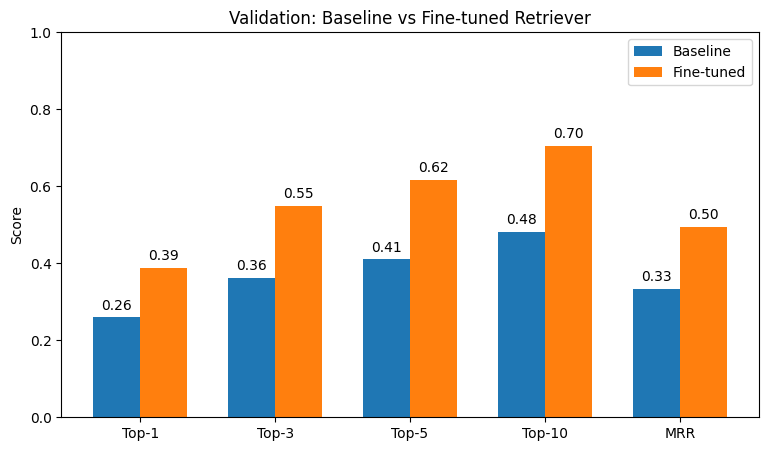

In [38]:
# [4.10] Compare baseline vs fine-tuned retriever

compare_metrics = ["Top-1", "Top-3", "Top-5", "Top-10", "MRR"]
baseline_values = [val_results[m] for m in compare_metrics]
finetuned_values = [ft_val_results[m] for m in compare_metrics]

x = np.arange(len(compare_metrics))
width = 0.35

plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - width/2, baseline_values, width, label="Baseline")
bars2 = plt.bar(x + width/2, finetuned_values, width, label="Fine-tuned")

plt.title("Validation: Baseline vs Fine-tuned Retriever")
plt.ylabel("Score")
plt.xticks(x, compare_metrics)
plt.ylim(0, 1)
plt.legend()

for bar, val in zip(bars1, baseline_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.2f}", ha="center")

for bar, val in zip(bars2, finetuned_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.2f}", ha="center")

plt.show()

Fine-tuning improves retrieval across all metrics.

The largest gain appears in Top-1, showing better first-choice precision.

In [39]:
# [4.11] Build Top-K candidates using fine-tuned retriever

TOP_K = 10

ft_topk_indices = np.argsort(-ft_similarity_matrix, axis=1)[:, :TOP_K]

ft_val_topk_candidates = []
for indices in ft_topk_indices:
    candidates = [idioms[idx] for idx in indices]
    ft_val_topk_candidates.append(candidates)

print("Example FT Top-K candidates:")
print(ft_val_topk_candidates[0])

Example FT Top-K candidates:
["'ark at 'ee", 'strike me pink', 'what the shit', 'ho there', 'what the crap', 'oh my gosh', 'I declare', 'What was that?', 'what the deuce', 'what the what']


Top-K candidates are regenerated using the fine-tuned retriever.

These candidates are expected to be more accurate than the baseline retrieval.

In [45]:
# [4.12] Rebuild full ranked candidates for baseline reranker

val_reranked_topk = []

for i, (query, candidate_texts) in enumerate(zip(val_queries, val_topk_candidate_texts)):
    pair_texts = [[query, cand] for cand in candidate_texts]
    scores = reranker.predict(pair_texts)

    reranked_order = np.argsort(-scores)
    reranked_candidates = [val_topk_candidates[i][j] for j in reranked_order]

    val_reranked_topk.append(reranked_candidates)

print("Baseline reranked candidate lists rebuilt.")
print("Example Top-5:", val_reranked_topk[0][:5])

Baseline reranked candidate lists rebuilt.
Example Top-5: ["'ark at 'ee", 'ho there', 'and I oop', 'what the shit', 'Sweet Mary Mother of God']


In [46]:
# [4.13] Compute baseline reranker full metrics (Top-K + MRR)

rerank_results = {}
top_k_values = [1, 3, 5, 10]

for k in top_k_values:
    hits = 0
    for i, true_idiom in enumerate(val_targets):
        top_k_idioms = val_reranked_topk[i][:k]
        if true_idiom in top_k_idioms:
            hits += 1
    rerank_results[f"Top-{k}"] = hits / len(val_targets)

reciprocal_ranks = []
for i, true_idiom in enumerate(val_targets):
    ranked_idioms = val_reranked_topk[i]
    if true_idiom in ranked_idioms:
        rank = ranked_idioms.index(true_idiom) + 1
        reciprocal_ranks.append(1 / rank)
    else:
        reciprocal_ranks.append(0.0)

rerank_results["MRR"] = np.mean(reciprocal_ranks)

for metric, value in rerank_results.items():
    print(f"{metric}: {value:.4f}")

Top-1: 0.3107
Top-3: 0.4103
Top-5: 0.4477
Top-10: 0.4811
MRR: 0.3680


> “Reranking improves performance for weak retrievers, but may degrade performance when the retriever is already well fine-tuned for the task.”

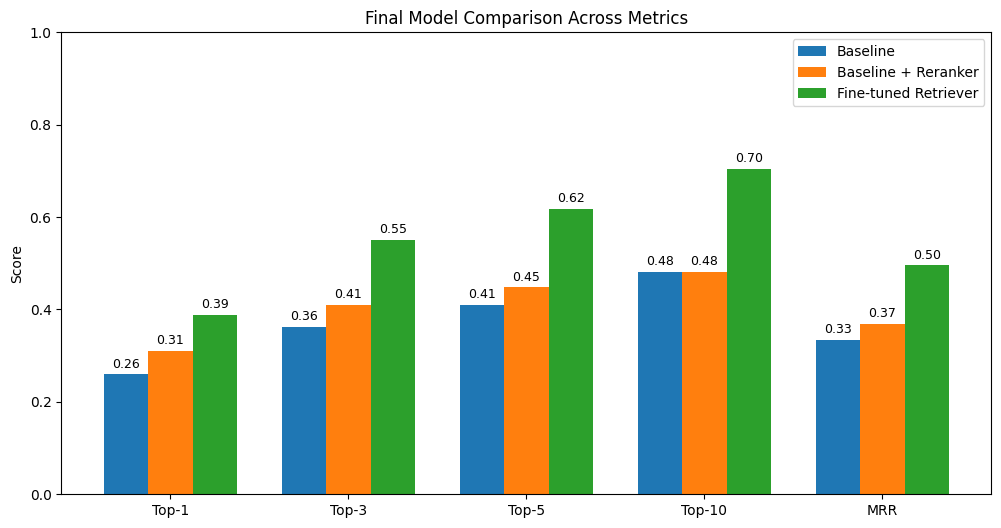

In [60]:
# [4.14] Final model comparison (Top-K + MRR) with values

models = [
    "Baseline",
    "Baseline + Reranker",
    "Fine-tuned Retriever"
]

metrics = ["Top-1", "Top-3", "Top-5", "Top-10", "MRR"]

baseline_vals = [val_results[m] for m in metrics]
baseline_rerank_vals = [rerank_results[m] for m in metrics]
ft_vals = [ft_val_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width, baseline_vals, width, label="Baseline")
bars2 = plt.bar(x, baseline_rerank_vals, width, label="Baseline + Reranker")
bars3 = plt.bar(x + width, ft_vals, width, label="Fine-tuned Retriever")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Final Model Comparison Across Metrics")
plt.ylim(0, 1)
plt.legend()

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.2f}",
            ha="center",
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.show()

Performance is evaluated across multiple metrics, including Top-K accuracy and MRR.

This provides a more complete view of retrieval quality beyond Top-1 accuracy.

## [5.1] Task-specific reranker training

The current bottleneck is ranking, not retrieval.

The fine-tuned retriever already places the correct idiom within the top candidates in many cases, but it does not always rank it first.

To improve Top-1 accuracy, we now train a task-specific reranker using:
- query text
- correct idiom as a positive pair
- hard negative idioms as negative pairs

Model:
- BAAI/bge-base-en-v1.5

In [68]:
# [5.1] Reranker training setup

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

reranker_model_name = "BAAI/bge-base-en-v1.5"

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

reranker_tokenizer = AutoTokenizer.from_pretrained(reranker_model_name)
reranker_model = AutoModelForSequenceClassification.from_pretrained(
    reranker_model_name,
    num_labels=2   # binary classification: correct vs hard negative
)

print("Loaded reranker model:", reranker_model_name)

CUDA available: True
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at BAAI/bge-base-en-v1.5 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded reranker model: BAAI/bge-base-en-v1.5


In [69]:
# [5.2] Build positive and negative reranker pairs

def parse_list_field(x):
    if pd.isna(x):
        return []
    x = str(x).strip()
    if not x:
        return []
    try:
        value = ast.literal_eval(x)
        if isinstance(value, list):
            return [str(v).strip() for v in value if str(v).strip()]
        return [str(value).strip()]
    except:
        return [x]

idiom_meaning_map = dict(
    zip(
        df_idiom_bank["idiom_canonical"],
        df_idiom_bank["idiom_canonical_meaning"].fillna("")
    )
)

hard_negative_map = dict(
    zip(
        df_task2["idiom_canonical"],
        df_task2["hard_negative_idioms"]
    )
)

reranker_rows = []

for _, row in df_train.iterrows():
    query = row["query_text"]
    true_idiom = row["idiom_canonical"]

    true_meaning = idiom_meaning_map.get(true_idiom, "")
    if query and true_meaning:
        reranker_rows.append({
            "query_text": query,
            "candidate_text": f"Idiom: {true_idiom}. Meaning: {true_meaning}",
            "label": 1
        })

    negatives = parse_list_field(hard_negative_map.get(true_idiom, ""))
    for neg_idiom in negatives:
        neg_meaning = idiom_meaning_map.get(neg_idiom, "")
        if query and neg_meaning:
            reranker_rows.append({
                "query_text": query,
                "candidate_text": f"Idiom: {neg_idiom}. Meaning: {neg_meaning}",
                "label": 0
            })

df_reranker_train = pd.DataFrame(reranker_rows)

print("Reranker training pairs:", df_reranker_train.shape)
print(df_reranker_train["label"].value_counts())
display(df_reranker_train.head(5))

Reranker training pairs: (370343, 3)
label
0    205866
1    164477
Name: count, dtype: int64


,query_text,candidate_text,label
0,"Calling attention to the sound, expressing alarm or surprise.","Idiom: 'ark at 'ee. Meaning: An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",1
1,"Calling attention to the sound, expressing alarm or surprise.","Idiom: listen up. Meaning: To pay close attention, often because important information is about to be communicated.",0
2,"Calling attention to the sound, expressing alarm or surprise.",Idiom: hear me out. Meaning: Please listen carefully to what I am going to say before making a judgment or decision.,0
3,"Calling attention to the sound, expressing alarm or surprise.",Idiom: look who's talking. Meaning: Used to point out someone's hypocrisy by indicating that they are guilty of the same fault they criticize in others.,0
4,Pay attention to what is being said,"Idiom: 'ark at 'ee. Meaning: An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",1


Each reranker training example is a query–candidate pair.

- label 1 = correct idiom
- label 0 = hard negative idiom

In [70]:
# [5.3] Build validation pairs for reranker evaluation

val_reranker_rows = []

for _, row in df_val.iterrows():
    query = row["query_text"]
    true_idiom = row["idiom_canonical"]

    true_meaning = idiom_meaning_map.get(true_idiom, "")
    if query and true_meaning:
        val_reranker_rows.append({
            "query_text": query,
            "candidate_text": f"Idiom: {true_idiom}. Meaning: {true_meaning}",
            "label": 1
        })

    negatives = parse_list_field(hard_negative_map.get(true_idiom, ""))
    for neg_idiom in negatives:
        neg_meaning = idiom_meaning_map.get(neg_idiom, "")
        if query and neg_meaning:
            val_reranker_rows.append({
                "query_text": query,
                "candidate_text": f"Idiom: {neg_idiom}. Meaning: {neg_meaning}",
                "label": 0
            })

df_reranker_val = pd.DataFrame(val_reranker_rows)

print("Reranker validation pairs:", df_reranker_val.shape)
print(df_reranker_val["label"].value_counts())
display(df_reranker_val.head(5))

Reranker validation pairs: (46444, 3)
label
0    25891
1    20553
Name: count, dtype: int64


,query_text,candidate_text,label
0,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","Idiom: 'ark at 'ee. Meaning: An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",1
1,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'","Idiom: listen up. Meaning: To pay close attention, often because important information is about to be communicated.",0
2,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Idiom: hear me out. Meaning: Please listen carefully to what I am going to say before making a judgment or decision.,0
3,"An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",Idiom: look who's talking. Meaning: Used to point out someone's hypocrisy by indicating that they are guilty of the same fault they criticize in others.,0
4,Expressing disbelief and drawing attention to a questionable statement.,"Idiom: 'ark at 'ee. Meaning: An exclamation used to draw attention to what someone is saying or to express surprise at their words; essentially, it means 'listen to you!' or 'listen to that!'",1


The reranker training set contains more negative than positive pairs.

This is expected because each query can have multiple hard negative idioms, while only one idiom is correct.

In [71]:
# [5.4] Tokenize reranker datasets

from datasets import Dataset

train_dataset = Dataset.from_pandas(df_reranker_train)
val_dataset = Dataset.from_pandas(df_reranker_val)

max_length = 256  # safe for your GPU

def tokenize_function(example):
    return reranker_tokenizer(
        example["query_text"],
        example["candidate_text"],
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print("Tokenization complete.")
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Map: 100%|██████████████████████████████████████████████████████████████| 46444/46444 [00:10<00:00, 4315.75 examples/s]

Tokenization complete.
Train size: 370343
Validation size: 46444


Query–candidate pairs are tokenized jointly and truncated to a fixed length.

This allows the reranker to model interaction between the query and idiom meaning.

In [72]:
# [5.5] Define metrics for reranker training

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_reranker_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Reranker metrics ready.")

Reranker metrics ready.


The reranker is evaluated as a binary classifier:

- label 1 = correct idiom
- label 0 = hard negative idiom

We report accuracy, precision, recall, and F1.

In [73]:
# [5.6] Training arguments for reranker

from transformers import TrainingArguments

reranker_training_args = TrainingArguments(
    output_dir="./task2_reranker_bge_base",
    eval_strategy="epoch",               # evaluate at the end of each epoch
    save_strategy="epoch",               # save one checkpoint per epoch
    logging_strategy="epoch",            # keep logs clean and readable
    learning_rate=2e-5,                  # standard transformer fine-tuning rate
    per_device_train_batch_size=8,       # safe for 12 GB GPU
    per_device_eval_batch_size=8,        # same for validation
    num_train_epochs=1,                  # start with 1 epoch for safety and speed
    weight_decay=0.01,                   # regularization
    load_best_model_at_end=True,         # keep the best checkpoint
    metric_for_best_model="eval_f1",     # choose best model by F1
    greater_is_better=True,
    report_to="none",                    # no external logger
    save_total_limit=1,                  # keep disk usage low
    fp16=torch.cuda.is_available()       # use mixed precision on GPU if available
)

print("Reranker training arguments ready.")

Reranker training arguments ready.


The reranker is trained with a conservative setup:
- small batch size
- one epoch first
- mixed precision on GPU if available

This keeps training stable on a local machine.

In [ ]:
# [5.7] Train reranker

from transformers import Trainer

reranker_trainer = Trainer(
    model=reranker_model,
    args=reranker_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=reranker_tokenizer,
    compute_metrics=compute_reranker_metrics
)

print("Starting reranker training...")
reranker_trainer.train()

print("Training completed.")

Starting reranker training...


Epoch,Training Loss,Validation Loss
